# Bike Sharing Data Analysis
**Nama**: Faradita Nur Azizah

**Email**: cdcc180d6x2437@student.devacademy.id

**ID Dicoding**: cdcc180d6x2437



## Pertanyaan Bisnis (SMART)

### Pertanyaan 1:
"Faktor apa yang paling memengaruhi jumlah penyewaan sepeda berdasarkan kondisi cuaca (weathersit) pada dataset Bike Sharing tahun 2011-2012?"

Keterangan:
- Specific: Fokus pada pengaruh "kondisi cuaca" terhadap "jumlah penyewaan sepeda".
- Measurable: Menggunakan rata-rata jumlah penyewaan sepeda sebagai metrik yang dapat diukur.
- Action-Oriented: Hasil analisis dapat digunakan untuk menentukan strategi seperti penyesuaian operasional atau promosi pada kondisi cuaca tertentu.
- Relevant: Cuaca merupakan faktor penting yang memengaruhi perilaku pengguna dalam menggunakan layanan bike sharing.
- Time-bound: Dibatasi pada periode tahun 2011-2012.

---

### Pertanyaan 2:
"Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan akhir pekan selama tahun 2011-2012?"

Keterangan:
- Specific: Fokus pada perbandingan antara "hari kerja" dan "akhir pekan".
- Measurable: Menggunakan rata-rata jumlah penyewaan sepeda sebagai indikator.
- Action-Oriented: Hasil analisis dapat digunakan untuk mengoptimalkan distribusi sepeda sesuai pola permintaan.
- Relevant: Perbedaan pola penggunaan antara hari kerja dan akhir pekan penting untuk operasional layanan.
- Time-bound: Dibatasi pada periode tahun 2011-2012.

In [50]:
import pandas as pd


In [51]:
day_df = pd.read_csv("day.csv")

In [52]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Data Wrangling - Gathering Data

Pada tahap data gathering, dilakukan proses pengumpulan data yang digunakan dalam analisis. Dataset yang digunakan adalah Bike Sharing Dataset yang terdiri dari file utama yaitu day.csv.

Dataset day.csv berisi data penyewaan sepeda per hari yang digunakan sebagai fokus utama dalam analisis.

## Data Wrangling - Assessing Data

Pada tahap ini dilakukan proses penilaian kualitas data untuk memastikan data siap dianalisis.

In [53]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Berdasarkan hasil pengecekan struktur data menggunakan fungsi `.info()`, diketahui bahwa dataset memiliki total 731 baris data dan 16 kolom.

Sebagian besar kolom memiliki tipe data numerik (int64 dan float64), sedangkan kolom `dteday` masih bertipe object. Hal ini menunjukkan bahwa kolom tersebut masih dalam format string dan perlu dikonversi menjadi tipe datetime agar dapat digunakan dalam analisis berbasis waktu.

Selain itu, tidak terdapat missing value pada seluruh kolom, yang ditunjukkan oleh jumlah Non-Null Count yang sama dengan jumlah total data, yaitu 731.

In [54]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [55]:
day_df.duplicated().sum()

np.int64(0)

Berdasarkan hasil pengecekan, tidak ditemukan data duplikat pada dataset, sehingga tidak diperlukan proses penghapusan data duplikat.

In [56]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Berdasarkan statistik deskriptif, terlihat bahwa data memiliki rentang nilai yang bervariasi pada setiap variabel. Nilai minimum, maksimum, serta rata-rata dapat digunakan untuk memahami distribusi data secara umum.

Namun, terdapat kemungkinan adanya nilai ekstrem (outlier), terutama pada kolom `cnt` sebagai jumlah penyewaan sepeda.

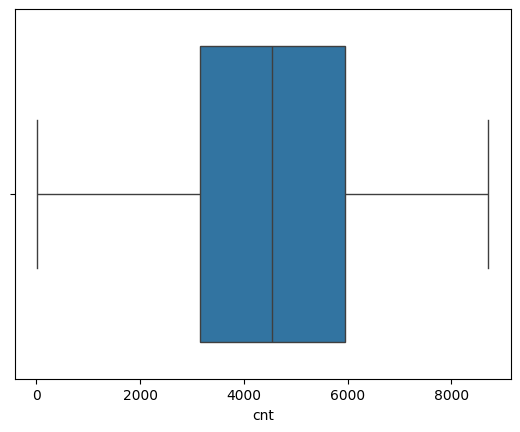

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=day_df['cnt'])
plt.show()

Berdasarkan visualisasi boxplot, terlihat adanya indikasi outlier pada kolom `cnt`. Outlier ini dapat memengaruhi hasil analisis sehingga perlu dipertimbangkan untuk ditangani pada tahap cleaning data.

### Permasalahan Data

Berdasarkan proses assessing data, ditemukan beberapa permasalahan sebagai berikut:

1. Kolom `dteday` masih bertipe object sehingga perlu dikonversi menjadi datetime.
2. Kolom kategorikal seperti `season` dan `weathersit` masih berupa angka sehingga kurang informatif.
3. Terdapat indikasi outlier pada kolom `cnt`.


## Data Wrangling - Cleaning Data

In [58]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

Pada tahap ini dilakukan perubahan tipe data pada kolom `dteday` dari object menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.

In [59]:
day_df['season'] = day_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain',
    4: 'Heavy Rain'
})

Dilakukan transformasi pada beberapa kolom kategorikal seperti `season` dan `weathersit` dari bentuk numerik menjadi label yang lebih deskriptif agar memudahkan interpretasi hasil analisis.

In [60]:
day_df.drop_duplicates(inplace=True)

Proses penghapusan data duplikat dilakukan untuk memastikan tidak terdapat data yang berulang. Namun, berdasarkan hasil sebelumnya, tidak ditemukan data duplikat pada dataset.

In [61]:
q1 = day_df['cnt'].quantile(0.25)
q3 = day_df['cnt'].quantile(0.75)
iqr = q3 - q1

outliers = day_df[(day_df['cnt'] < q1 - 1.5*iqr) |
                  (day_df['cnt'] > q3 + 1.5*iqr)]

len(outliers)

0

Outlier hanya dianalisis tanpa dihapus

Setelah dilakukan proses cleaning data, dataset telah siap digunakan untuk tahap analisis selanjutnya, yaitu Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### Pertanyaan 1:
Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

In [62]:
day_df.groupby('weathersit')['cnt'].mean()

,cnt
weathersit,
Clear,4876.786177
Light Rain,1803.285714
Mist,4035.862348


Berdasarkan hasil analisis, terlihat bahwa rata-rata jumlah penyewaan sepeda berbeda pada setiap kondisi cuaca. Cuaca cerah memiliki jumlah penyewaan tertinggi, sedangkan cuaca buruk seperti hujan memiliki jumlah penyewaan yang lebih rendah.

Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda.

### Pertanyaan 2:
Bagaimana perbedaan jumlah penyewaan sepeda antara hari kerja dan akhir pekan?


In [63]:
day_df.groupby('workingday')['cnt'].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


Hasil analisis menunjukkan bahwa terdapat perbedaan jumlah penyewaan sepeda antara hari kerja dan akhir pekan. Jumlah penyewaan cenderung lebih tinggi pada hari kerja dibandingkan akhir pekan.

Hal ini mengindikasikan bahwa sepeda lebih banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah.

In [64]:
day_df.groupby('season')['cnt'].mean()

,cnt
season,
Fall,5644.303191
Spring,2604.132597
Summer,4992.331522
Winter,4728.162921


Jumlah penyewaan sepeda juga bervariasi berdasarkan musim. Musim dengan cuaca yang lebih nyaman cenderung memiliki jumlah penyewaan yang lebih tinggi dibandingkan musim lainnya.

Untuk memperjelas hasil analisis, dilakukan visualisasi data sebagai berikut.

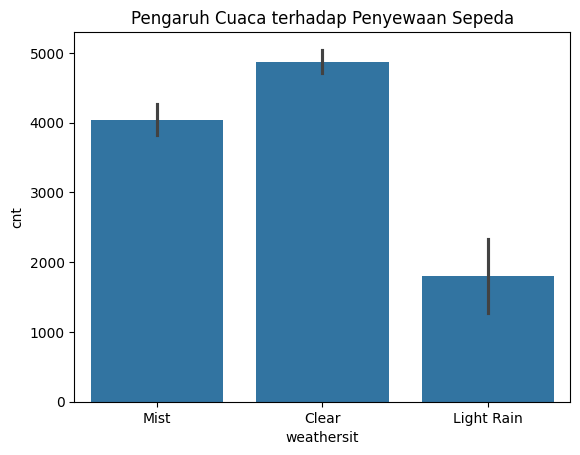

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='weathersit', y='cnt', data=day_df)
plt.title('Pengaruh Cuaca terhadap Penyewaan Sepeda')
plt.show()

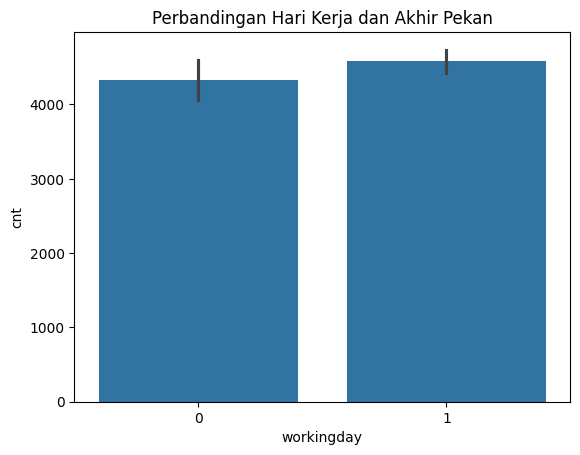

In [66]:
sns.barplot(x='workingday', y='cnt', data=day_df)
plt.title('Perbandingan Hari Kerja dan Akhir Pekan')
plt.show()

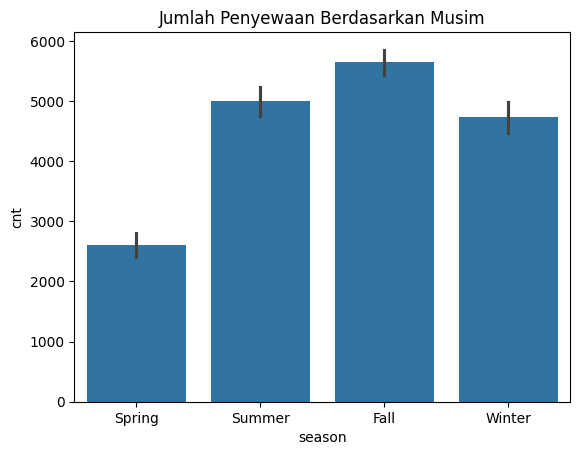

In [67]:
sns.barplot(x='season', y='cnt', data=day_df)
plt.title('Jumlah Penyewaan Berdasarkan Musim')
plt.show()

Berdasarkan hasil exploratory data analysis, dapat disimpulkan bahwa faktor cuaca, hari kerja, dan musim memiliki pengaruh terhadap jumlah penyewaan sepeda. Cuaca cerah dan hari kerja menunjukkan jumlah penyewaan yang lebih tinggi dibandingkan kondisi lainnya.

Hasil ini dapat digunakan sebagai dasar dalam pengambilan keputusan untuk meningkatkan penggunaan layanan bike sharing.

### Visualisasi Pertanyaan 1:
Pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda

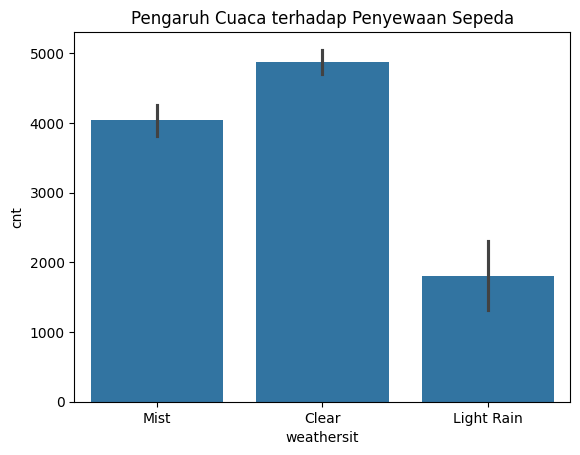

In [68]:
sns.barplot(x='weathersit', y='cnt', data=day_df)
plt.title('Pengaruh Cuaca terhadap Penyewaan Sepeda')
plt.show()

Berdasarkan visualisasi di atas, terlihat bahwa kondisi cuaca sangat memengaruhi jumlah penyewaan sepeda. Cuaca cerah memiliki jumlah penyewaan tertinggi, sedangkan kondisi cuaca buruk seperti hujan menunjukkan jumlah penyewaan yang lebih rendah.

Hal ini menunjukkan bahwa faktor cuaca menjadi salah satu penentu utama dalam penggunaan layanan bike sharing.

### Visualisasi Pertanyaan 2:
Perbandingan jumlah penyewaan sepeda antara hari kerja dan akhir pekan

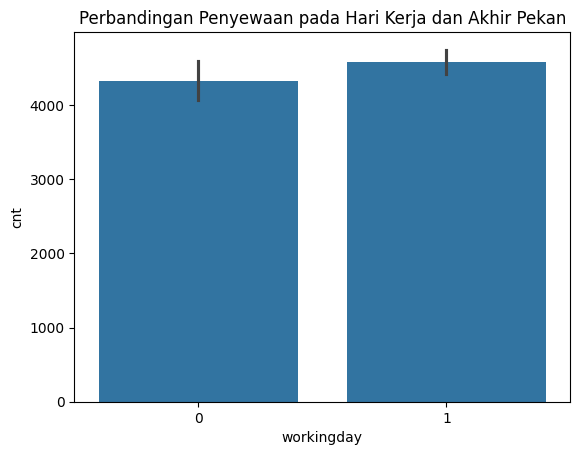

In [69]:
sns.barplot(x='workingday', y='cnt', data=day_df)
plt.title('Perbandingan Penyewaan pada Hari Kerja dan Akhir Pekan')
plt.show()

Berdasarkan visualisasi, terlihat bahwa jumlah penyewaan sepeda lebih tinggi pada hari kerja dibandingkan akhir pekan. Hal ini menunjukkan bahwa sepeda lebih banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah.

Informasi ini dapat dimanfaatkan untuk mengoptimalkan distribusi sepeda pada hari kerja.

## Conclusion & Recommendation

### Kesimpulan 1

Berdasarkan hasil analisis dan visualisasi, dapat disimpulkan bahwa kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Cuaca cerah menunjukkan jumlah penyewaan tertinggi, sedangkan kondisi cuaca buruk seperti hujan menyebabkan penurunan jumlah penyewaan.

Hal ini menunjukkan bahwa faktor cuaca menjadi salah satu faktor utama yang memengaruhi perilaku pengguna dalam menggunakan layanan bike sharing.

### Kesimpulan 2

Berdasarkan analisis yang telah dilakukan, ditemukan bahwa jumlah penyewaan sepeda lebih tinggi pada hari kerja dibandingkan akhir pekan. Hal ini menunjukkan bahwa sepeda lebih banyak digunakan untuk kebutuhan transportasi rutin seperti bekerja atau sekolah.

Dengan demikian, pola penggunaan sepeda cenderung meningkat pada hari kerja dibandingkan hari libur.

### Rekomendasi

Berdasarkan kesimpulan yang diperoleh, terdapat beberapa rekomendasi yang dapat dilakukan untuk meningkatkan penggunaan layanan bike sharing:

1. Menyediakan promosi atau diskon khusus pada kondisi cuaca buruk untuk meningkatkan minat pengguna dalam menyewa sepeda.
2. Mengoptimalkan jumlah dan distribusi sepeda pada hari kerja, terutama pada jam sibuk, untuk memenuhi tingginya permintaan pengguna.
3. Menyediakan fasilitas tambahan seperti tempat berteduh atau perlengkapan pelindung untuk meningkatkan kenyamanan pengguna saat kondisi cuaca kurang mendukung.